In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data = {
    "Year": [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],

    "Fatalities": [1, 6, 6, 2, 1, 0, 1, 0],

    "Injuries": [171, 222, 160, 164, 199, 203, 223, 192],

    "Lifting": [111, 169, 274, 259, 333, 375, 388, 401],

    "Fires": [77, 84, 87, 117, 126, 149, 160, 182],

    "Explosions": [3, 4, 1, 4, 1, 0, 2, 2],

    "Musters": [82, 87, 81, 79, 108, 108, 123, 134],

    "Gas_Releases": [19, 20, 73, 44, 57, 106, 121, 121],

    "Collisions": [6, 10, 7, 3, 6, 8, 10, 11],

    "Loss_of_Well_Control": [1, 2, 1, 4, 5, 5, 0, 0],

    "Spills_1BBL_or_More": [19, 14, 11, 14, 17, 12, 13, 9]
}

df_offshore = pd.DataFrame(data)

df_offshore

,Year,Fatalities,Injuries,Lifting,Fires,Explosions,Musters,Gas_Releases,Collisions,Loss_of_Well_Control,Spills_1BBL_or_More
0,2018,1,171,111,77,3,82,19,6,1,19
1,2019,6,222,169,84,4,87,20,10,2,14
2,2020,6,160,274,87,1,81,73,7,1,11
3,2021,2,164,259,117,4,79,44,3,4,14
4,2022,1,199,333,126,1,108,57,6,5,17
5,2023,0,203,375,149,0,108,106,8,5,12
6,2024,1,223,388,160,2,123,121,10,0,13
7,2025,0,192,401,182,2,134,121,11,0,9


In [3]:
print(df_offshore.shape)
print()
print(df_offshore.dtypes)
print()
print(df_offshore.isna().sum())

(8, 11)

Year                    int64
Fatalities              int64
Injuries                int64
Lifting                 int64
Fires                   int64
Explosions              int64
Musters                 int64
Gas_Releases            int64
Collisions              int64
Loss_of_Well_Control    int64
Spills_1BBL_or_More     int64
dtype: object

Year                    0
Fatalities              0
Injuries                0
Lifting                 0
Fires                   0
Explosions              0
Musters                 0
Gas_Releases            0
Collisions              0
Loss_of_Well_Control    0
Spills_1BBL_or_More     0
dtype: int64


In [4]:
incident_columns = [
    "Fatalities",
    "Injuries",
    "Lifting",
    "Fires",
    "Explosions",
    "Musters",
    "Gas_Releases",
    "Collisions",
    "Loss_of_Well_Control",
    "Spills_1BBL_or_More"
]

category_totals = (
    df_offshore[incident_columns]
    .sum()
    .sort_values(ascending=False)
)

category_totals

,0
Lifting,2310
Injuries,1534
Fires,982
Musters,802
Gas_Releases,561
Spills_1BBL_or_More,109
Collisions,61
Loss_of_Well_Control,18
Fatalities,17
Explosions,17


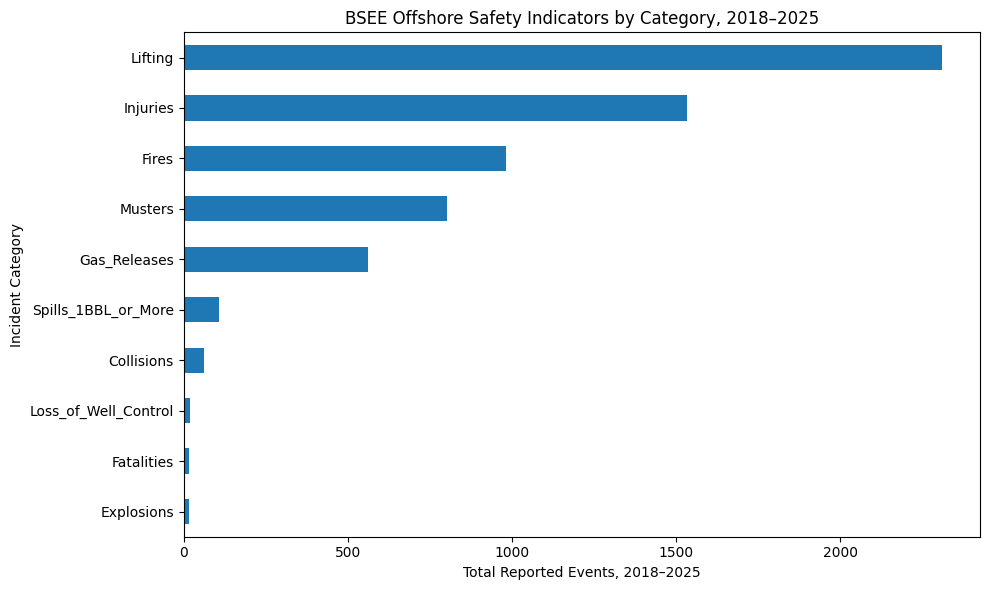

In [5]:
plt.figure(figsize=(10, 6))

category_totals.sort_values().plot(kind="barh")

plt.xlabel("Total Reported Events, 2018–2025")
plt.ylabel("Incident Category")
plt.title("BSEE Offshore Safety Indicators by Category, 2018–2025")

plt.tight_layout()

plt.savefig(
    "offshore_incident_category_totals.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

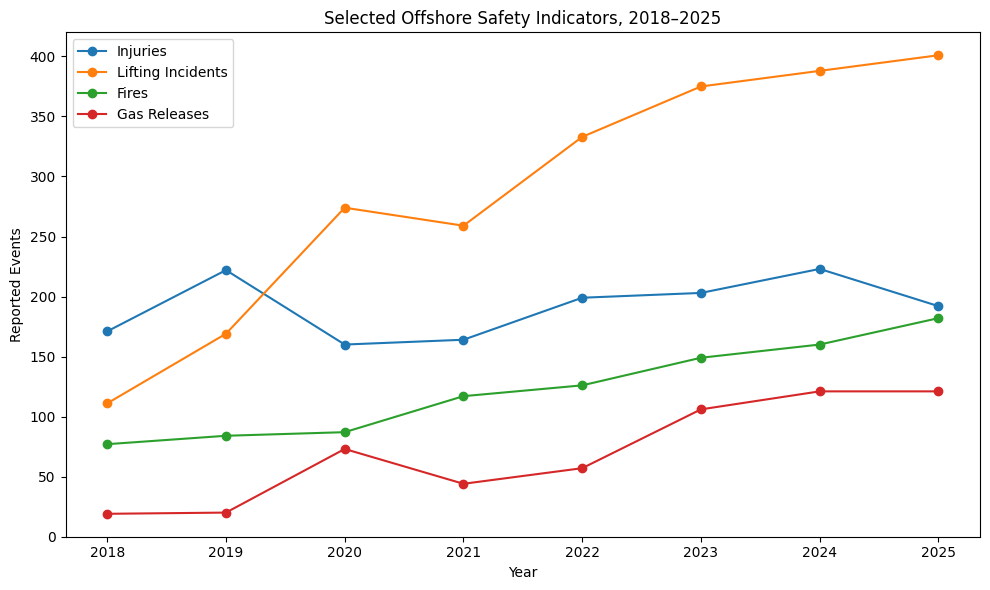

In [6]:
plt.figure(figsize=(10, 6))

plt.plot(
    df_offshore["Year"],
    df_offshore["Injuries"],
    marker="o",
    label="Injuries"
)

plt.plot(
    df_offshore["Year"],
    df_offshore["Lifting"],
    marker="o",
    label="Lifting Incidents"
)

plt.plot(
    df_offshore["Year"],
    df_offshore["Fires"],
    marker="o",
    label="Fires"
)

plt.plot(
    df_offshore["Year"],
    df_offshore["Gas_Releases"],
    marker="o",
    label="Gas Releases"
)

plt.xlabel("Year")
plt.ylabel("Reported Events")
plt.title("Selected Offshore Safety Indicators, 2018–2025")
plt.legend()

plt.tight_layout()

plt.savefig(
    "offshore_incident_trends.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
trend_summary = []

for column in [
    "Injuries",
    "Lifting",
    "Fires",
    "Gas_Releases"
]:
    start = df_offshore.loc[
        df_offshore["Year"] == 2018,
        column
    ].iloc[0]

    end = df_offshore.loc[
        df_offshore["Year"] == 2025,
        column
    ].iloc[0]

    percent_change = ((end - start) / start) * 100

    trend_summary.append({
        "Indicator": column,
        "2018": start,
        "2025": end,
        "Percent_change": round(percent_change, 1)
    })

trend_summary = pd.DataFrame(trend_summary)

trend_summary

,Indicator,2018,2025,Percent_change
0,Injuries,171,192,12.3
1,Lifting,111,401,261.3
2,Fires,77,182,136.4
3,Gas_Releases,19,121,536.8


In [8]:
risk_profile = pd.DataFrame({
    "Indicator": [
        "Lifting",
        "Injuries",
        "Fires",
        "Gas Releases",
        "Fatalities",
        "Loss of Well Control",
        "Explosions"
    ],
    "Total_2018_2025": [
        category_totals["Lifting"],
        category_totals["Injuries"],
        category_totals["Fires"],
        category_totals["Gas_Releases"],
        category_totals["Fatalities"],
        category_totals["Loss_of_Well_Control"],
        category_totals["Explosions"]
    ]
})

risk_profile.sort_values(
    "Total_2018_2025",
    ascending=False
)

,Indicator,Total_2018_2025
0,Lifting,2310
1,Injuries,1534
2,Fires,982
3,Gas Releases,561
5,Loss of Well Control,18
4,Fatalities,17
6,Explosions,17


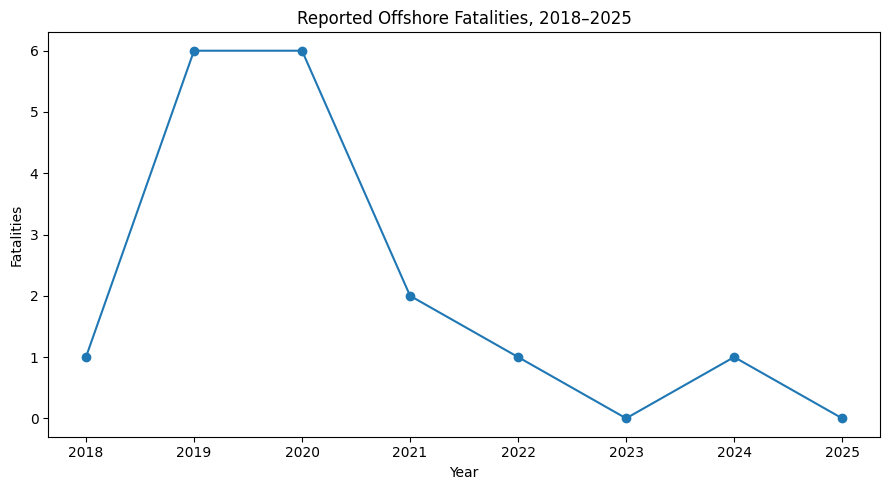

In [9]:
plt.figure(figsize=(9, 5))

plt.plot(
    df_offshore["Year"],
    df_offshore["Fatalities"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Fatalities")
plt.title("Reported Offshore Fatalities, 2018–2025")

plt.xticks(df_offshore["Year"])

plt.tight_layout()

plt.savefig(
    "offshore_fatalities_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

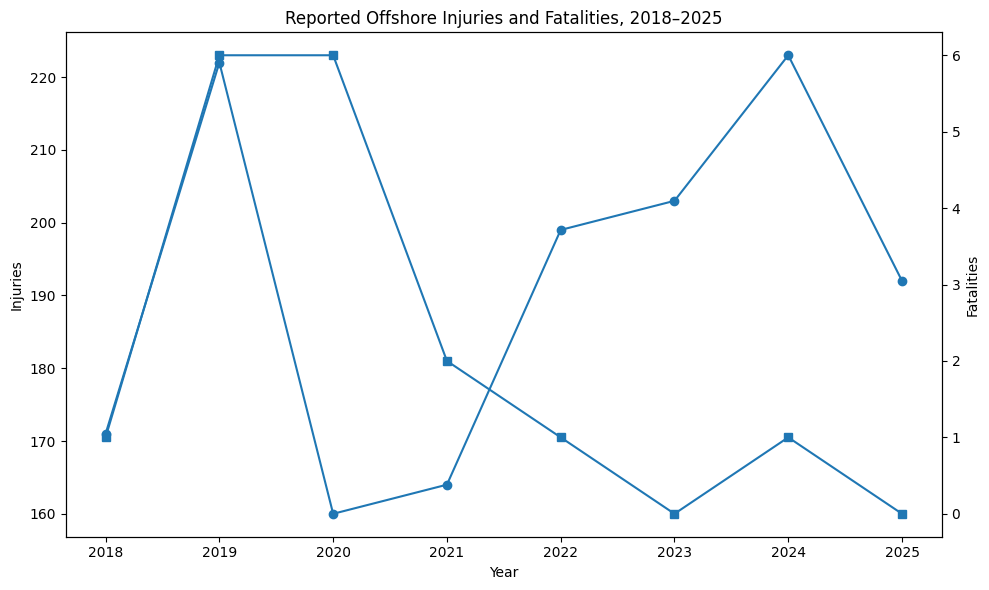

In [10]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(
    df_offshore["Year"],
    df_offshore["Injuries"],
    marker="o",
    label="Injuries"
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Injuries")

ax2 = ax1.twinx()

ax2.plot(
    df_offshore["Year"],
    df_offshore["Fatalities"],
    marker="s",
    label="Fatalities"
)

ax2.set_ylabel("Fatalities")

plt.title("Reported Offshore Injuries and Fatalities, 2018–2025")

fig.tight_layout()

plt.savefig(
    "offshore_injuries_vs_fatalities.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
category_totals.to_csv(
    "offshore_category_totals.csv"
)

trend_summary.to_csv(
    "offshore_trend_summary.csv",
    index=False
)

risk_profile.to_csv(
    "offshore_risk_profile.csv",
    index=False
)

print("Files saved.")

Files saved.


In [12]:
trend_columns = [
    "Injuries",
    "Lifting",
    "Fires",
    "Gas_Releases"
]

indexed_trends = df_offshore[["Year"] + trend_columns].copy()

for column in trend_columns:
    baseline = indexed_trends.loc[
        indexed_trends["Year"] == 2018,
        column
    ].iloc[0]

    indexed_trends[column] = (
        indexed_trends[column] / baseline
    ) * 100

indexed_trends.round(1)

,Year,Injuries,Lifting,Fires,Gas_Releases
0,2018,100.0,100.0,100.0,100.0
1,2019,129.8,152.3,109.1,105.3
2,2020,93.6,246.8,113.0,384.2
3,2021,95.9,233.3,151.9,231.6
4,2022,116.4,300.0,163.6,300.0
5,2023,118.7,337.8,193.5,557.9
6,2024,130.4,349.5,207.8,636.8
7,2025,112.3,361.3,236.4,636.8


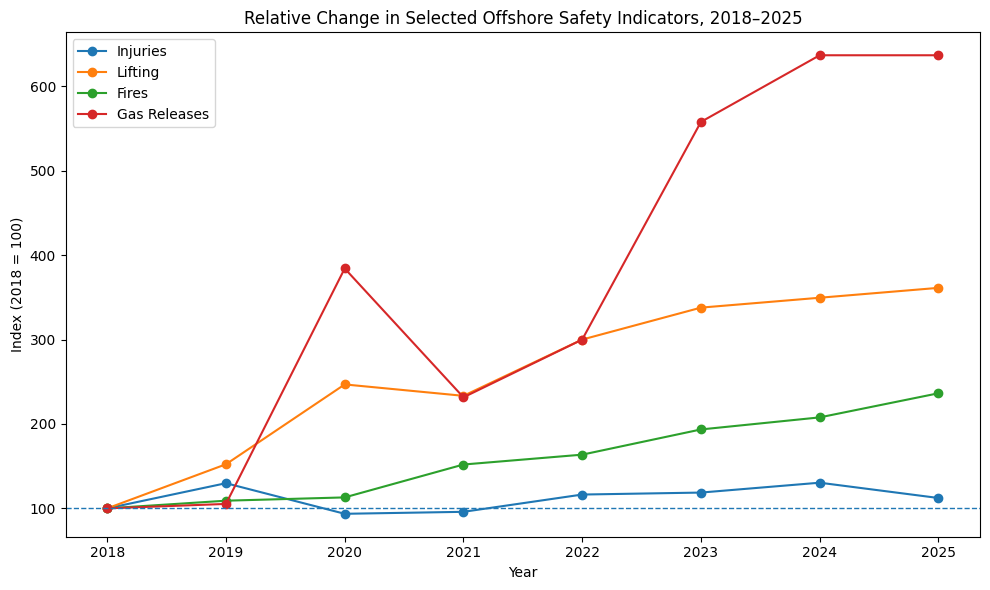

In [13]:
plt.figure(figsize=(10, 6))

for column in trend_columns:
    plt.plot(
        indexed_trends["Year"],
        indexed_trends[column],
        marker="o",
        label=column.replace("_", " ")
    )

plt.axhline(
    y=100,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Year")
plt.ylabel("Index (2018 = 100)")
plt.title(
    "Relative Change in Selected Offshore Safety Indicators, 2018–2025"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    "offshore_safety_indexed_trends.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
annual_average = (
    df_offshore[incident_columns]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

annual_average

,0
Lifting,288.75
Injuries,191.75
Fires,122.75
Musters,100.25
Gas_Releases,70.12
Spills_1BBL_or_More,13.62
Collisions,7.62
Loss_of_Well_Control,2.25
Fatalities,2.12
Explosions,2.12


In [15]:
priority_summary = pd.DataFrame({
    "Indicator": [
        "Lifting Incidents",
        "Gas Releases",
        "Fires",
        "Injuries"
    ],
    "2018": [
        111,
        19,
        77,
        171
    ],
    "2025": [
        401,
        121,
        182,
        192
    ],
    "Percent_Change": [
        261.3,
        536.8,
        136.4,
        12.3
    ]
})

priority_summary

,Indicator,2018,2025,Percent_Change
0,Lifting Incidents,111,401,261.3
1,Gas Releases,19,121,536.8
2,Fires,77,182,136.4
3,Injuries,171,192,12.3


In [16]:
priority_summary["Trend_Category"] = pd.cut(
    priority_summary["Percent_Change"],
    bins=[-float("inf"), 25, 100, 250, float("inf")],
    labels=[
        "Relatively stable",
        "Moderate increase",
        "Large increase",
        "Very large increase"
    ]
)

priority_summary

,Indicator,2018,2025,Percent_Change,Trend_Category
0,Lifting Incidents,111,401,261.3,Very large increase
1,Gas Releases,19,121,536.8,Very large increase
2,Fires,77,182,136.4,Large increase
3,Injuries,171,192,12.3,Relatively stable


In [17]:
indexed_trends.to_csv(
    "offshore_indexed_trends.csv",
    index=False
)

annual_average.to_csv(
    "offshore_annual_average.csv"
)

priority_summary.to_csv(
    "offshore_monitoring_priority.csv",
    index=False
)

print("Files saved successfully.")

Files saved successfully.
